# SVM Classifier — Baseline

## Structure: Support Vector Machine (RBF kernel)

```
SVM finds the maximum-margin hyperplane in feature space:

  Input   : centre pixel spectral features  (1 × 172 bands → 16 PCA)
  Kernel  : RBF  K(x,y) = exp(-γ||x-y||²)
  Output  : class label  (one-vs-one multiclass)

  Key difference vs TTN:
    SVM uses ONLY the centre pixel (1 spatial site, 16 PCA features)
    TTN uses ALL 49 spatial sites simultaneously (7×7 patch)
    This makes SVM a spectral-only baseline —
    any accuracy gap reflects the value of spatial context.
```

## Role in paper
- Traditional ML baseline — no spatial context, no learned hierarchy
- Directly comparable to TTN results on same labels/test set
- C parameter ablation = equivalent of TTN bond dimension ablation
- If SVM ≈ TTN accuracy: spatial context adds no value (unlikely)
- If SVM << TTN accuracy: spatial hierarchy is the key contribution


In [1]:
OUTPUT_DIR = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\aviris_refl_outputs"
SVM_DIR    = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\svm_outputs"

D_PCA       = 16        # same PCA as TTN models for fair comparison
RANDOM_SEED = 42
PATCH_SIZE  = 7

# SVM hyperparameters
SVM_C       = 10        # regularisation — tuned in ablation cell
SVM_GAMMA   = 'scale'   # RBF bandwidth — 1/(n_features * X.var())
SVM_KERNEL  = 'rbf'

# Training subset — SVM does not scale to 800k samples
# 50k gives a representative sample and trains in ~10-20 minutes
TRAIN_SUBSET = 500_000

import os
os.makedirs(SVM_DIR, exist_ok=True)
print("Config loaded.")
print(f"  Kernel       : {SVM_KERNEL.upper()} (C={SVM_C}, gamma={SVM_GAMMA})")
print(f"  Train subset : {TRAIN_SUBSET:,}  (from full training set)")
print(f"  PCA dims     : {D_PCA}  (same as TTN models)")
print(f"  Input        : centre pixel only (1 of 49 spatial sites)")

Config loaded.
  Kernel       : RBF (C=10, gamma=scale)
  Train subset : 500,000  (from full training set)
  PCA dims     : 16  (same as TTN models)
  Input        : centre pixel only (1 of 49 spatial sites)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import IncrementalPCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import time, os

np.random.seed(RANDOM_SEED)

X_train = np.load(os.path.join(OUTPUT_DIR, "patches_train.npy"), mmap_mode='r')
X_test  = np.load(os.path.join(OUTPUT_DIR, "patches_test.npy"),  mmap_mode='r')
y_train = np.load(os.path.join(OUTPUT_DIR, "labels_train.npy"))
y_test  = np.load(os.path.join(OUTPUT_DIR, "labels_test.npy"))
meta    = np.load(os.path.join(OUTPUT_DIR, "class_info.npz"), allow_pickle=True)

CLASS_NAMES = list(meta['class_names'])
N_CLASSES   = len(CLASS_NAMES)
N_TRAIN, P, _, B = X_train.shape
N_TEST    = X_test.shape[0]
N_SPATIAL = P * P

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Classes ({N_CLASSES}): {CLASS_NAMES}")

Train : (799996, 7, 7, 172)
Test  : (200000, 7, 7, 172)
Classes (8): ['Celestite', 'Sand', 'Andradite', 'Richterite', 'Microcline', 'Sepiolite', 'Mizzonite', 'Uvarovite']


In [3]:
print("-"*55)
print("STEP A — Spectral PCA  (B → 16 per spatial site)")
print("-"*55)

# Fit PCA on centre pixels — same as TTN for fair comparison
cx       = PATCH_SIZE // 2   # centre pixel index = 3
N_FIT    = 50_000
fit_idx  = np.random.choice(N_TRAIN, N_FIT, replace=False)
X_fit    = np.array(X_train[fit_idx][:, cx, cx, :], dtype=np.float32)

pca = IncrementalPCA(n_components=D_PCA, batch_size=10_000)
pca.fit(X_fit)
print(f"  Explained variance : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PCA fitted on {N_FIT:,} centre pixels ✓")

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def accuracy(y_true, y_pred):
    return (y_pred == y_true).mean()

print("  PCA + utilities ready ✓")

-------------------------------------------------------
STEP A — Spectral PCA  (B → 16 per spatial site)
-------------------------------------------------------
  Explained variance : 99.6%
  PCA fitted on 50,000 centre pixels ✓
  PCA + utilities ready ✓


In [4]:
print("\n" + "-"*55)
print("STEP B — Feature extraction (centre pixel, PCA)")
print("-"*55)

# SVM uses centre pixel only — spectral features, no spatial context
# This is different from TTN which uses all 49 spatial sites
# Centre pixel = most representative spectral signature of the patch
cx = PATCH_SIZE // 2   # = 3 for 7x7 patch

# Extract centre pixel PCA features for train subset
print(f"  Extracting centre pixel features for {TRAIN_SUBSET:,} train samples ...")
tr_idx      = np.random.choice(N_TRAIN, TRAIN_SUBSET, replace=False)
X_tr_raw    = np.array(X_train[tr_idx][:, cx, cx, :], dtype=np.float32)
X_tr_pca    = pca.transform(X_tr_raw)                 # (TRAIN_SUBSET, 16)
y_tr        = y_train[tr_idx]

# Extract centre pixel PCA features for full test set
print(f"  Extracting centre pixel features for {N_TEST:,} test samples ...")
X_te_raw    = np.array(X_test[:, cx, cx, :], dtype=np.float32)  # (N_TEST, B)
X_te_pca    = pca.transform(X_te_raw)                 # (N_TEST, 16)

print(f"  Train features : {X_tr_pca.shape}  (TRAIN_SUBSET × D_PCA)")
print(f"  Test  features : {X_te_pca.shape}  (N_TEST × D_PCA)")
print(f"  Feature range  : [{X_tr_pca.min():.3f}, {X_tr_pca.max():.3f}]")
print()
print(f"  NOTE: SVM sees 1 spatial site (centre pixel, 16 PCA features)")
print(f"        TTN sees {N_SPATIAL} spatial sites (7×7 patch, {D_PCA} PCA per site)")
print(f"        → accuracy gap reflects value of spatial context")


-------------------------------------------------------
STEP B — Feature extraction (centre pixel, PCA)
-------------------------------------------------------
  Extracting centre pixel features for 500,000 train samples ...
  Extracting centre pixel features for 200,000 test samples ...
  Train features : (500000, 16)  (TRAIN_SUBSET × D_PCA)
  Test  features : (200000, 16)  (N_TEST × D_PCA)
  Feature range  : [-23.547, 39.065]

  NOTE: SVM sees 1 spatial site (centre pixel, 16 PCA features)
        TTN sees 49 spatial sites (7×7 patch, 16 PCA per site)
        → accuracy gap reflects value of spatial context


In [5]:
print("-"*55)
print("STEP C — SVM model definition")
print("-"*55)

model = SVC(
    kernel      = SVM_KERNEL,
    C           = SVM_C,
    gamma       = SVM_GAMMA,
    decision_function_shape = 'ovr',   # one-vs-rest multiclass
    random_state = RANDOM_SEED,
    probability  = True                # needed for class probabilities
)

print(f"  SVC configured:")
print(f"    kernel  : {SVM_KERNEL.upper()}")
print(f"    C       : {SVM_C}  (regularisation — larger = tighter fit)")
print(f"    gamma   : {SVM_GAMMA}  (RBF bandwidth)")
print(f"    classes : {N_CLASSES}  (one-vs-rest)")
print(f"  SVM ready ✓")

# Sanity check — class distribution in training subset
print(f"\n  Train subset class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_tr == i).sum()
    bar   = '█' * int(count / max(1, len(y_tr) // 400))
    print(f"    [{i}] {name:<15} {count:>6,}  {bar}")

-------------------------------------------------------
STEP C — SVM model definition
-------------------------------------------------------
  SVC configured:
    kernel  : RBF
    C       : 10  (regularisation — larger = tighter fit)
    gamma   : scale  (RBF bandwidth)
    classes : 8  (one-vs-rest)
  SVM ready ✓

  Train subset class distribution:
    [0] Celestite       109,609  ███████████████████████████████████████████████████████████████████████████████████████
    [1] Sand            140,224  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    [2] Andradite       92,938  ██████████████████████████████████████████████████████████████████████████
    [3] Richterite      62,468  █████████████████████████████████████████████████
    [4] Microcline      17,876  ██████████████
    [5] Sepiolite       10,130  ████████
    [6] Mizzonite       42,555  ██████████████████████████████████
    [7] Uvarovite       24,200  ███

In [6]:
print("-"*55)
print("STEP D — Training (SVM fit)")
print("-"*55)
print(f"  Fitting SVM on {TRAIN_SUBSET:,} samples ...")
print(f"  (SVM has no epochs — single fit call)")

t0 = time.time()
model.fit(X_tr_pca, y_tr)
t_fit = time.time() - t0

print(f"  Fit complete in {t_fit:.0f}s")
print(f"  Support vectors : {model.n_support_.sum():,}  total")
print(f"  Per class       : {dict(zip(CLASS_NAMES, model.n_support_))}")

# Train accuracy on subset
t0 = time.time()
y_tr_pred = model.predict(X_tr_pca)
train_acc = accuracy(y_tr, y_tr_pred)
print(f"  Train accuracy  : {train_acc*100:.2f}%  ({time.time()-t0:.1f}s)")

# Save model
import pickle
with open(os.path.join(SVM_DIR, "svm_best.pkl"), 'wb') as f:
    pickle.dump(model, f)
print(f"  Saved svm_best.pkl ✓")

# History dict (for consistent structure with other classifiers)
history = {
    'train_acc' : [train_acc],
    'fit_time_s': [t_fit],
    'n_support' : [int(model.n_support_.sum())]
}

-------------------------------------------------------
STEP D — Training (SVM fit)
-------------------------------------------------------
  Fitting SVM on 500,000 samples ...
  (SVM has no epochs — single fit call)
  Fit complete in 858s
  Support vectors : 13,233  total
  Per class       : {'Celestite': 2986, 'Sand': 3295, 'Andradite': 2354, 'Richterite': 1827, 'Microcline': 306, 'Sepiolite': 747, 'Mizzonite': 1088, 'Uvarovite': 630}
  Train accuracy  : 99.90%  (433.0s)
  Saved svm_best.pkl ✓



C PARAMETER STUDY — SVM  (equivalent of bond dim ablation)
  C controls regularisation — equivalent role to χ in TTN
  Small C → smoother boundary, may underfit
  Large C → tighter fit to training data, may overfit

  Ablation subset : 20,000 train  |  5,000 val

  ── C = 0.1 ──────────────────────────────────
    C=0.1    | val_acc=0.9802 | n_support=6,626 | 3s

  ── C = 1 ──────────────────────────────────
    C=1      | val_acc=0.9902 | n_support=3,197 | 2s

  ── C = 10 ──────────────────────────────────
    C=10     | val_acc=0.9930 | n_support=1,586 | 1s

  ── C = 100 ──────────────────────────────────
    C=100    | val_acc=0.9930 | n_support=837 | 1s

  ── C = 1000 ──────────────────────────────────
    C=1000   | val_acc=0.9932 | n_support=531 | 0s


  C PARAMETER STUDY SUMMARY
         C    Val Acc     N Support   Time(s)
  ---------------------------------------------
       0.1     0.9802         6,626         3
         1     0.9902         3,197         2
        10     0

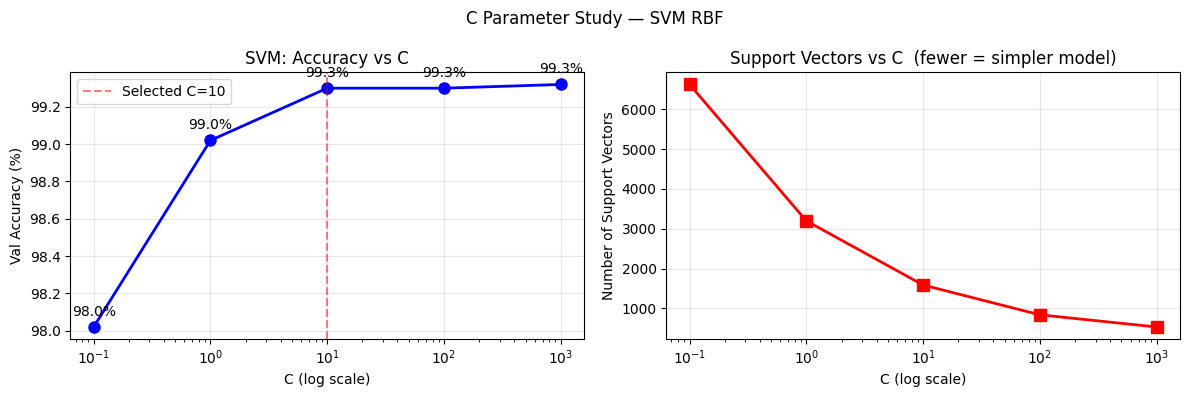

  Saved ablation_C_svm.png ✓


In [7]:
print("\n" + "="*55)
print("C PARAMETER STUDY — SVM  (equivalent of bond dim ablation)")
print("="*55)
print("  C controls regularisation — equivalent role to χ in TTN")
print("  Small C → smoother boundary, may underfit")
print("  Large C → tighter fit to training data, may overfit")
print()

# Use a smaller subset for speed during ablation
ABL_SIZE = 20_000
abl_idx  = np.random.choice(TRAIN_SUBSET, ABL_SIZE, replace=False)
X_abl    = X_tr_pca[abl_idx]
y_abl    = y_tr[abl_idx]

# Use 5k test subset for speed
abl_val_idx = np.random.choice(N_TEST, 5_000, replace=False)
X_abl_val   = X_te_pca[abl_val_idx]
y_abl_val   = y_test[abl_val_idx]
print(f"  Ablation subset : {ABL_SIZE:,} train  |  5,000 val")

C_VALUES        = [0.1, 1, 10, 100, 1000]
ablation_results_svm = []

for C in C_VALUES:
    print(f"\n  ── C = {C} ──────────────────────────────────")
    t0  = time.time()
    svm_c = SVC(kernel=SVM_KERNEL, C=C, gamma=SVM_GAMMA,
                random_state=RANDOM_SEED)
    svm_c.fit(X_abl, y_abl)

    val_pred = svm_c.predict(X_abl_val)
    val_acc  = accuracy(y_abl_val, val_pred)
    elapsed  = time.time() - t0

    ablation_results_svm.append({
        'C'       : C,
        'val_acc' : val_acc,
        'n_sv'    : int(svm_c.n_support_.sum()),
        'time_s'  : elapsed
    })
    print(f"    C={C:<6} | val_acc={val_acc:.4f} | "
          f"n_support={svm_c.n_support_.sum():,} | {elapsed:.0f}s")

np.save(os.path.join(SVM_DIR, "ablation_results_svm.npy"), ablation_results_svm)

print("\n\n  C PARAMETER STUDY SUMMARY")
print(f"  {'C':>8}  {'Val Acc':>9}  {'N Support':>12}  {'Time(s)':>8}")
print("  " + "-"*45)
for r in ablation_results_svm:
    print(f"  {r['C']:>8}  {r['val_acc']:>9.4f}  "
          f"{r['n_sv']:>12,}  {r['time_s']:>8.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

Cs   = [r['C']       for r in ablation_results_svm]
accs = [r['val_acc'] for r in ablation_results_svm]
svs  = [r['n_sv']    for r in ablation_results_svm]

ax = axes[0]
ax.semilogx(Cs, [a*100 for a in accs], 'bo-', markersize=8, linewidth=2)
for C, acc in zip(Cs, accs):
    ax.annotate(f'{acc*100:.1f}%', (C, acc*100),
                textcoords="offset points", xytext=(0, 8), ha='center')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('Val Accuracy (%)')
ax.set_title('SVM: Accuracy vs C')
ax.grid(True, alpha=0.3)
ax.axvline(SVM_C, color='red', linestyle='--', alpha=0.5,
           label=f'Selected C={SVM_C}')
ax.legend()

ax = axes[1]
ax.semilogx(Cs, svs, 'rs-', markersize=8, linewidth=2)
ax.set_xlabel('C (log scale)'); ax.set_ylabel('Number of Support Vectors')
ax.set_title('Support Vectors vs C  (fewer = simpler model)')
ax.grid(True, alpha=0.3)

plt.suptitle('C Parameter Study — SVM RBF', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SVM_DIR, 'ablation_C_svm.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("  Saved ablation_C_svm.png ✓")

In [8]:
print("-"*55)
print("STEP E — Full test evaluation")
print("-"*55)

# Load best saved model
import pickle
with open(os.path.join(SVM_DIR, "svm_best.pkl"), 'rb') as f:
    best_model = pickle.load(f)
print("  Loaded svm_best.pkl ✓")

# Predict in batches — SVC.predict_proba is slow on large sets
EVAL_BATCH = 10_000
all_preds, all_probs = [], []

print(f"  Running inference on {N_TEST:,} test samples ...")
t0 = time.time()
for start in range(0, N_TEST, EVAL_BATCH):
    end        = min(start + EVAL_BATCH, N_TEST)
    X_chunk    = X_te_pca[start:end]
    preds      = best_model.predict(X_chunk)
    probs      = best_model.predict_proba(X_chunk)
    all_preds.append(preds)
    all_probs.append(probs)
    print(f"  {end:,}/{N_TEST:,}", end='\r')

y_pred   = np.concatenate(all_preds)
y_prob   = np.concatenate(all_probs)
test_acc = accuracy(y_test, y_pred)
t_infer  = time.time() - t0

print(f"\n  Inference time   : {t_infer:.0f}s")
print(f"  Test Accuracy    : {test_acc*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))
np.savez(os.path.join(SVM_DIR, "test_predictions.npz"),
         y_pred=y_pred, y_prob=y_prob, y_true=y_test)

-------------------------------------------------------
STEP E — Full test evaluation
-------------------------------------------------------
  Loaded svm_best.pkl ✓
  Running inference on 200,000 test samples ...
  200,000/200,000
  Inference time   : 317s
  Test Accuracy    : 99.86%

              precision    recall  f1-score   support

   Celestite       1.00      1.00      1.00     43900
        Sand       1.00      1.00      1.00     56053
   Andradite       1.00      1.00      1.00     37200
  Richterite       1.00      1.00      1.00     25052
  Microcline       1.00      1.00      1.00      7047
   Sepiolite       1.00      0.99      0.99      4014
   Mizzonite       1.00      1.00      1.00     17015
   Uvarovite       1.00      1.00      1.00      9719

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



-------------------------------------------------------
STEP F — Visualisation
-------------------------------------------------------


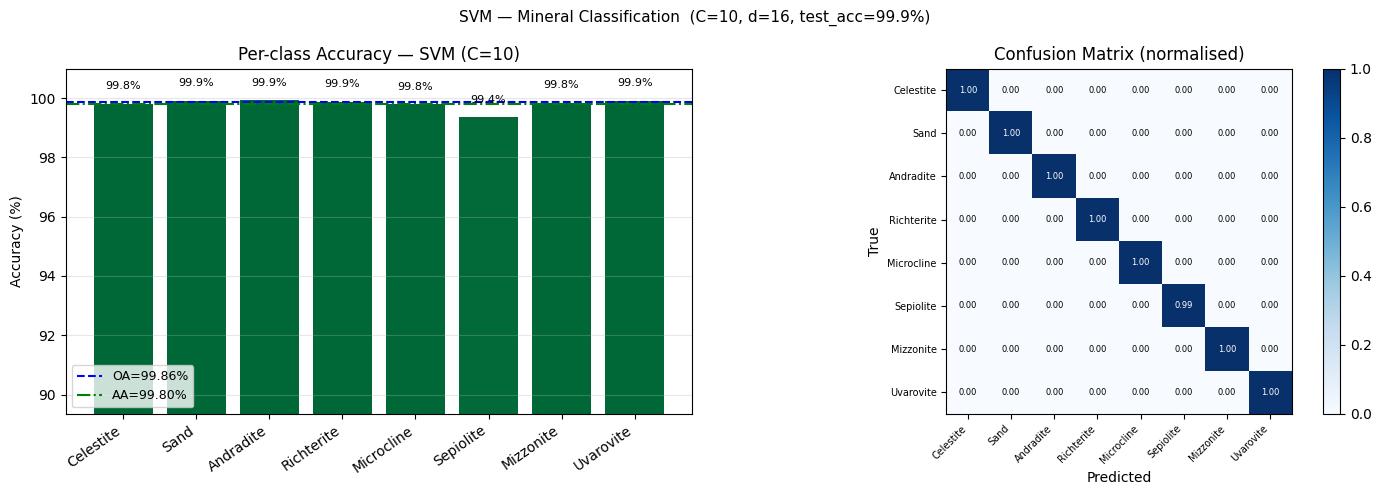


        SVM CLASSIFIER COMPLETE
  Classifier   : SVM (RBF kernel)
  C            : 10
  Input        : centre pixel, 16 PCA features
  Train subset : 500,000 samples
  Support vecs : 13,233
  Test acc     : 99.86%


In [9]:
print("-"*55)
print("STEP F — Visualisation")
print("-"*55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Per-class accuracy bar
cm        = confusion_matrix(y_test, y_pred, normalize='true')
per_class = cm.diagonal()
OA_plot   = (y_pred == y_test).mean() * 100
AA_plot   = per_class.mean() * 100

ax = axes[0]
colors_bar = plt.cm.RdYlGn(per_class)
bars = ax.bar(CLASS_NAMES, per_class*100, color=colors_bar)
ax.axhline(OA_plot, color='blue',  linestyle='--',
           linewidth=1.5, label=f'OA={OA_plot:.2f}%')
ax.axhline(AA_plot, color='green', linestyle='-.',
           linewidth=1.5, label=f'AA={AA_plot:.2f}%')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Per-class Accuracy — SVM (C={SVM_C})')
ax.set_ylim(max(0, per_class.min()*100-10), 101)
ax.legend(fontsize=9)
for bar, v in zip(bars, per_class):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.5,
            f'{v*100:.1f}%', ha='center', fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Confusion matrix
ax = axes[1]
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(CLASS_NAMES, fontsize=7)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix (normalised)')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                fontsize=6, color='white' if cm[i,j]>0.5 else 'black')

plt.suptitle(f'SVM — Mineral Classification  '
             f'(C={SVM_C}, d={D_PCA}, test_acc={test_acc*100:.1f}%)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SVM_DIR, 'svm_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("        SVM CLASSIFIER COMPLETE")
print("="*55)
print(f"  Classifier   : SVM ({SVM_KERNEL.upper()} kernel)")
print(f"  C            : {SVM_C}")
print(f"  Input        : centre pixel, {D_PCA} PCA features")
print(f"  Train subset : {TRAIN_SUBSET:,} samples")
print(f"  Support vecs : {best_model.n_support_.sum():,}")
print(f"  Test acc     : {test_acc*100:.2f}%")
print("="*55)


EXTENDED METRICS — OA / AA / κ  +  SAM Validation  (SVM)

── Standard HSI Metrics ─────────────────────────────
  Overall Accuracy (OA)  : 99.86%
  Average Accuracy (AA)  : 99.80%
  Kappa coefficient  (κ) : 0.9983

  Per-class accuracy:
    [0] Celestite        99.79%  █████████████████████████████
    [1] Sand             99.90%  █████████████████████████████
    [2] Andradite        99.92%  █████████████████████████████
    [3] Richterite       99.87%  █████████████████████████████
    [4] Microcline       99.79%  █████████████████████████████
    [5] Sepiolite        99.35%  █████████████████████████████
    [6] Mizzonite        99.84%  █████████████████████████████
    [7] Uvarovite        99.90%  █████████████████████████████

── SAM Validation (spectral angle vs USGS library) ──
  Loaded band_metadata — 172 bands
  USGS library : 1050 spectra loaded

  Computing SAM angles for correctly classified pixels ...
    8,192/10,000

  SAM Validation Results:
  Class             Mean An

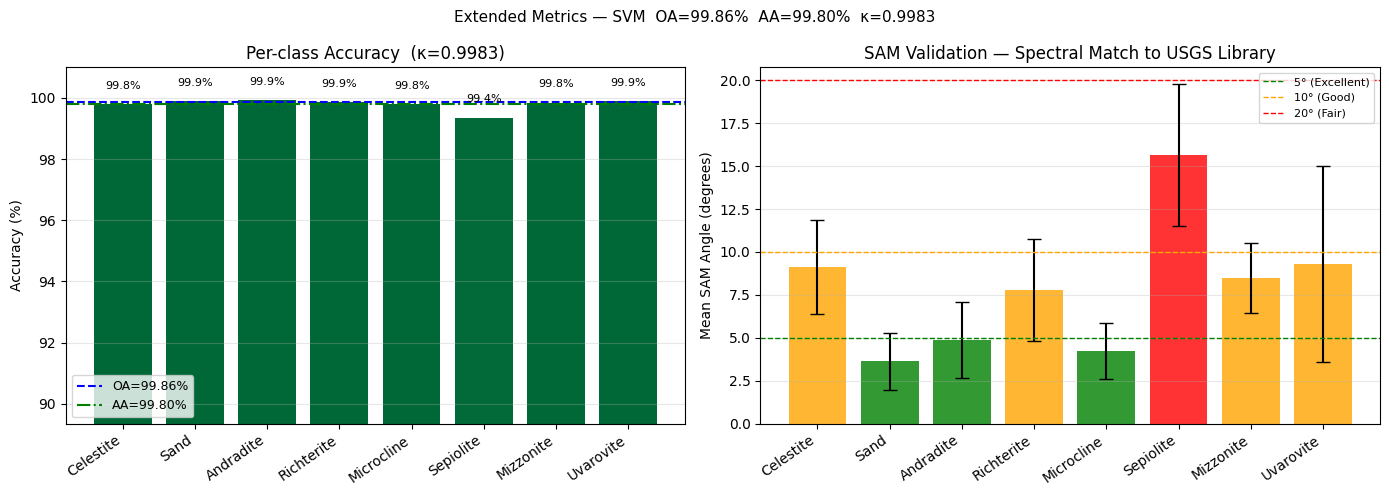

  Saved extended_metrics_svm.png ✓

  METRICS SUMMARY FOR PAPER — SVM
  OA    : 99.86%
  AA    : 99.80%
  κ     : 0.9983
  Mean SAM angle (correctly classified) : 7.88°


In [10]:
print("\n" + "="*55)
print("EXTENDED METRICS — OA / AA / κ  +  SAM Validation  (SVM)")
print("="*55)

from sklearn.metrics import cohen_kappa_score
import os

# ══════════════════════════════════════════════════════════════
# PART 1 — OA, AA, Kappa
# ══════════════════════════════════════════════════════════════
print("\n── Standard HSI Metrics ─────────────────────────────")

OA = (y_pred == y_test).mean() * 100

per_class_acc = np.array([
    ((y_pred == y_test) & (y_test == c)).sum() / max((y_test == c).sum(), 1)
    for c in range(N_CLASSES)
])
AA    = per_class_acc.mean() * 100
kappa = cohen_kappa_score(y_test, y_pred)

print(f"  Overall Accuracy (OA)  : {OA:.2f}%")
print(f"  Average Accuracy (AA)  : {AA:.2f}%")
print(f"  Kappa coefficient  (κ) : {kappa:.4f}")
print()
print(f"  Per-class accuracy:")
for i, (name, acc) in enumerate(zip(CLASS_NAMES, per_class_acc)):
    bar = '█' * int(acc * 30)
    print(f"    [{i}] {name:<15} {acc*100:>6.2f}%  {bar}")

# ══════════════════════════════════════════════════════════════
# PART 2 — SAM Validation
# ══════════════════════════════════════════════════════════════
print("\n── SAM Validation (spectral angle vs USGS library) ──")

LIBRARY_DIR = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\usgs_splib07\ASCIIdata\ASCIIdata_splib07b_cvAVIRISc2014"
CHAPTERS    = ["ChapterM_Minerals", "ChapterS_SoilsAndMixtures"]
wl_file = r"C:\Users\PESU-RF\Desktop\Capstone Team - 88\usgs_splib07\ASCIIdata\ASCIIdata_splib07b_cvAVIRISc2014\s07_AV14_Wavelengths_in_microns_224_ch_AVIRIS14a.txt"

sensor_wl = []
with open(wl_file, errors="ignore") as f:
    for i, line in enumerate(f):
        if i == 0: continue
        line = line.strip()
        if not line: continue
        try:
            sensor_wl.append(float(line) * 1000)
        except ValueError:
            continue
sensor_wl = np.array(sensor_wl)

def load_chapter_sam(chapter_dir, sensor_wl, target_wl):
    names, spectra = [], []
    for fname in sorted([f for f in os.listdir(chapter_dir) if f.endswith(".txt")]):
        refl = []
        with open(os.path.join(chapter_dir, fname), errors="ignore") as f:
            for i, line in enumerate(f):
                if i == 0: continue
                line = line.strip()
                if not line: continue
                try: refl.append(float(line))
                except ValueError: continue
        if len(refl) < 10: continue
        refl    = np.array(refl, dtype=np.float32)
        refl    = np.where(refl < -0.1, np.nan, refl)
        min_len = min(len(refl), len(sensor_wl))
        refl    = refl[:min_len]; wl_use = sensor_wl[:min_len]
        valid   = ~np.isnan(refl)
        if valid.sum() < 10: continue
        refl    = np.clip(refl[valid], 0, 1); wl_use = wl_use[valid]
        interp  = np.interp(target_wl, wl_use, refl, left=np.nan, right=np.nan)
        if np.isnan(interp).any(): continue
        parts   = fname.replace(".txt","").split("_")
        names.append(parts[2] if len(parts) > 2 else fname)
        spectra.append(interp.astype(np.float32))
    return names, spectra

try:
    meta_bands = np.load(os.path.join(OUTPUT_DIR, "band_metadata.npz"))
    target_wl  = meta_bands['wavelengths']
    band_mean  = meta_bands['band_mean']
    band_std   = meta_bands['band_std']
    print(f"  Loaded band_metadata — {len(target_wl)} bands")
except:
    print("  WARNING: band_metadata.npz not found — skipping SAM validation")
    target_wl = None

if target_wl is not None:
    all_names, all_spectra = [], []
    for chapter in CHAPTERS:
        n, s = load_chapter_sam(
            os.path.join(LIBRARY_DIR, chapter), sensor_wl, target_wl)
        all_names.extend(n); all_spectra.extend(s)
    lib_spectra = np.array(all_spectra, dtype=np.float32)
    print(f"  USGS library : {len(all_names)} spectra loaded")

    class_lib_idx = []
    for cls_name in CLASS_NAMES:
        matches = [i for i, n in enumerate(all_names)
                   if cls_name.lower() in n.lower()]
        class_lib_idx.append(matches[0] if matches else None)
        if not matches:
            print(f"  WARNING: '{cls_name}' not found in USGS library")

    print(f"\n  Computing SAM angles for correctly classified pixels ...")
    correct_mask = (y_pred == y_test)
    correct_idx  = np.where(correct_mask)[0]
    sam_sample   = np.random.choice(correct_idx,
                                    min(10_000, len(correct_idx)), replace=False)

    def sam_angle_batch(a, b):
        dot    = a @ b
        norm_a = np.linalg.norm(a, axis=1)
        norm_b = np.linalg.norm(b)
        cos    = dot / (norm_a * norm_b + 1e-10)
        return np.degrees(np.arccos(np.clip(cos, -1, 1)))

    sam_angles_per_class = {i: [] for i in range(N_CLASSES)}
    EVAL_BATCH = 512

    for start in range(0, len(sam_sample), EVAL_BATCH):
        batch_idx = sam_sample[start:start+EVAL_BATCH]
        # SVM uses centre pixel — load raw patch centre pixel
        X_raw     = np.array(X_test[batch_idx], dtype=np.float32)
        cx        = PATCH_SIZE // 2
        px        = X_raw[:, cx, cx, :]
        px_refl   = px * band_std + band_mean
        labels_b  = y_test[batch_idx]

        for j, (spectrum, label) in enumerate(zip(px_refl, labels_b)):
            lib_idx = class_lib_idx[label]
            if lib_idx is None: continue
            angle = float(sam_angle_batch(
                spectrum[np.newaxis, :], lib_spectra[lib_idx])[0])
            sam_angles_per_class[label].append(angle)

        if (start // EVAL_BATCH) % 5 == 0:
            print(f"    {min(start+EVAL_BATCH, len(sam_sample)):,}"
                  f"/{len(sam_sample):,}", end='\r')

    print(f"\n\n  SAM Validation Results:")
    print(f"  {'Class':<15} {'Mean Angle':>12} {'Std':>8} "
          f"{'N pixels':>10} {'Quality':>10}")
    print("  " + "-"*60)

    sam_summary = []
    for i, name in enumerate(CLASS_NAMES):
        angles = sam_angles_per_class[i]
        if len(angles) == 0:
            print(f"  {name:<15} {'N/A':>12}"); continue
        mean_a  = np.mean(angles); std_a = np.std(angles)
        quality = ('Excellent' if mean_a < 5 else 'Good' if mean_a < 10
                   else 'Fair' if mean_a < 20 else 'Poor')
        sam_summary.append({'class': name, 'mean': mean_a,
                            'std': std_a, 'n': len(angles), 'quality': quality})
        print(f"  {name:<15} {mean_a:>11.2f}° {std_a:>7.2f}° "
              f"{len(angles):>10,} {quality:>10}")

    overall_sam = np.mean([s['mean'] for s in sam_summary if s])
    print(f"\n  Overall mean SAM angle : {overall_sam:.2f}°")

    np.savez(os.path.join(SVM_DIR, "extended_metrics_svm.npz"),
             OA=OA, AA=AA, kappa=kappa,
             per_class_acc=per_class_acc,
             sam_summary=np.array(sam_summary, dtype=object),
             overall_sam=overall_sam)
    print("\n  Saved extended_metrics_svm.npz ✓")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    colors_bar = plt.cm.RdYlGn(per_class_acc)
    bars = ax.bar(CLASS_NAMES, per_class_acc*100, color=colors_bar)
    ax.axhline(OA, color='blue',  linestyle='--', linewidth=1.5,
               label=f'OA={OA:.2f}%')
    ax.axhline(AA, color='green', linestyle='-.', linewidth=1.5,
               label=f'AA={AA:.2f}%')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Per-class Accuracy  (κ={kappa:.4f})')
    ax.set_ylim(max(0, per_class_acc.min()*100-10), 101)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, per_class_acc):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v*100:.1f}%', ha='center', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
    ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    sam_names  = [s['class'] for s in sam_summary]
    sam_means  = [s['mean']  for s in sam_summary]
    sam_stds   = [s['std']   for s in sam_summary]
    sam_colors = ['green' if m < 5 else 'orange' if m < 10 else 'red'
                  for m in sam_means]
    ax.bar(sam_names, sam_means, color=sam_colors,
           yerr=sam_stds, capsize=5, alpha=0.8)
    ax.axhline(5,  color='green',  linestyle='--', linewidth=1, label='5° (Excellent)')
    ax.axhline(10, color='orange', linestyle='--', linewidth=1, label='10° (Good)')
    ax.axhline(20, color='red',    linestyle='--', linewidth=1, label='20° (Fair)')
    ax.set_ylabel('Mean SAM Angle (degrees)')
    ax.set_title('SAM Validation — Spectral Match to USGS Library')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right')

    plt.suptitle(
        f'Extended Metrics — SVM  '
        f'OA={OA:.2f}%  AA={AA:.2f}%  κ={kappa:.4f}',
        fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(SVM_DIR, 'extended_metrics_svm.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved extended_metrics_svm.png ✓")

    print("\n" + "="*55)
    print("  METRICS SUMMARY FOR PAPER — SVM")
    print("="*55)
    print(f"  OA    : {OA:.2f}%")
    print(f"  AA    : {AA:.2f}%")
    print(f"  κ     : {kappa:.4f}")
    print(f"  Mean SAM angle (correctly classified) : {overall_sam:.2f}°")
    print("="*55)